In [116]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Cargar archivos JSON
try:
    with open("data/productos.json", "r", encoding="utf-8") as f:
        df_productos = pd.DataFrame(json.load(f))
except FileNotFoundError:
    df_productos = pd.DataFrame()

try:
    with open("data/transacciones.json", "r", encoding="utf-8") as f:
        df_tx = pd.DataFrame(json.load(f))
except FileNotFoundError:
    df_tx = pd.DataFrame()

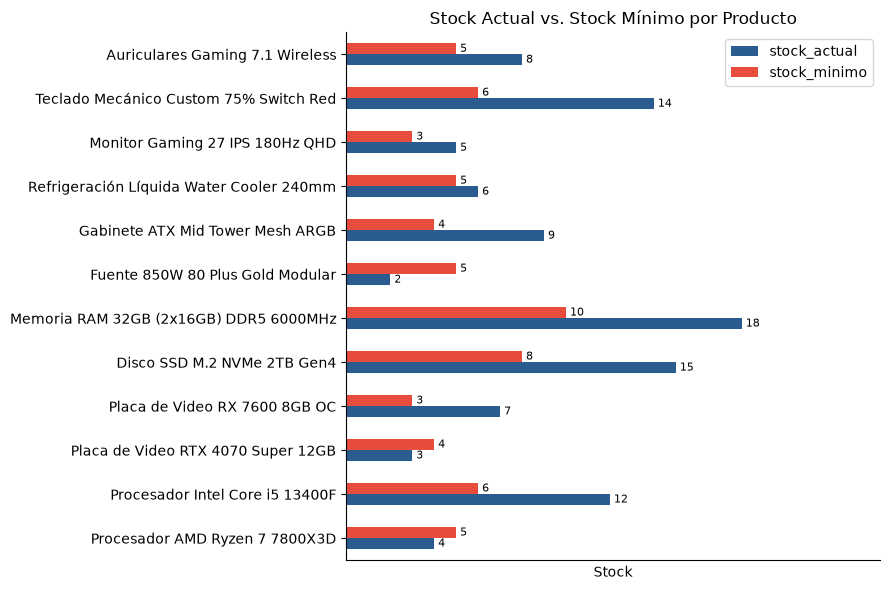

In [117]:
# ==========================================
# Gráfico 1: Stock actual vs. stock minimo por producto
# ==========================================

# 1. Crear el gráfico de barras horizontales
ax = df_productos.plot.barh(
    x="nombre", 
    y=["stock_actual", "stock_minimo"], 
    color=["#2b5c8f", "#e74c3c"],
    figsize=(9, 6)
)

# 2. Iterar sobre los dos series de barras (contenedores) del de stock_actual y stock_minimo para agregar las etiquetas numéricas a la derecha de cada barra
for c in ax.containers:
    ax.bar_label(
        c,
        padding=3,
        fontsize=8
    )

# 3. Ocultar números y marcas del eje X
ax.tick_params(bottom=False, labelbottom=False)

# 4. Ocultar bordes superior y derecho (spines)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 5. Configurar título y ajustar límites para que no se corten los textos
max_val = df_productos[["stock_actual", "stock_minimo"]].values.max()
ax.set(
    title="Stock Actual vs. Stock Mínimo por Producto",
    ylabel="",
    xlabel="Stock",
    xlim=(0, max_val * 1.35)
)

plt.tight_layout()
plt.show()

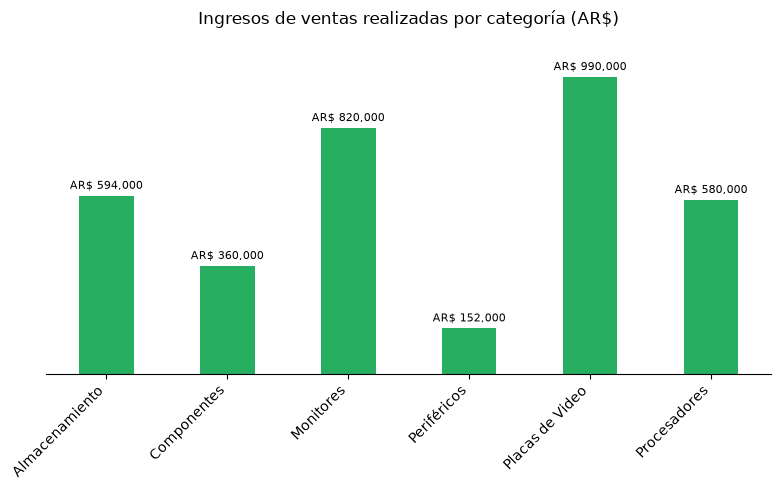

In [118]:
# ==========================================
# Gráfico 2: Ingresos de ventas realizadas por categoría
# ==========================================

# 1. Validar que existan transacciones de tipo VENTA
if not df_tx.empty and "tipo" in df_tx.columns and not df_tx[df_tx["tipo"] == "VENTA"].empty:
    
    # Unir ventas con catálogo para obtener categorías y sumar montos
    df_ventas = df_tx[df_tx["tipo"] == "VENTA"].merge(df_productos[["id_producto", "categoria"]], on="id_producto")
    df_ingresos = df_ventas.groupby("categoria")["monto_total"].sum().reset_index()

    # Crear figura y barras
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(df_ingresos["categoria"], df_ingresos["monto_total"], color="#27ae60", width=0.45)

    # Estética limpia: título, límites y remoción de eje Y y bordes
    ax.set(
        title="Ingresos de ventas realizadas por categoría (AR$)",
        ylim=(0, df_ingresos["monto_total"].max() * 1.15)
    )
    ax.tick_params(left=False, labelleft=False)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Agregar las etiquetas de montos sobre cada barra (con formato)
    ax.bar_label(
        bars,
        labels=[f"AR$ {v:,.0f}" for v in df_ingresos["monto_total"]],
        padding=3,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ No se puede generar el gráfico: aún no hay ventas registradas.")